## **Hepatitis C Virus (HCV) for Egyptian patients**

Group members :
Rachel SHERPA, Estelle SOBESKY, Koralie THERESINE, Yasmine ZEROUAL

**STEP 1 - Import libraries and load the dataset**

In [1]:
!pip install ucimlrepo

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# evaluation
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, f1_score,
roc_auc_score, roc_curve)

# imbalanced data
from collections import Counter
#from imblearn.over_sampling import SMOTE, RandomOverSampler
#from imblearn.under_sampling import RandomUnderSampler

from sklearn.decomposition import PCA


# Informations on the dataset

The dataset used in this project is the Hepatitis C Virus (HCV) for Egyptian patients dataset, obtained from the UCI Machine Learning Repository.

It contains clinical, demographic and laboratory information from 1385 Egyptian patients infected with the Hepatitis C Virus (HCV).
Each record included variables such as age, BMI, blood test results, RNA measurements collected at different treatment stages.

The target variable, called Baseline Histological Staging, represents the stage of liver fibrosis (F0-F3), which indicates the progression of liver damage in HCV patients.
The goal of this dataset is to enable the prediction of the fibrosis stage based on these medical features.

This topic was chosen because Hepatitis C remains a major public health issue in many countries, and using machine learning models to predict liver fibrosis can help improve early diagnosis and patient management. It has a real impact on the world.

**STEP 2 - Load the dataset**

In [6]:
# ML tools
from ucimlrepo import fetch_ucirepo

# Fetch dataset (UCI id = 503)
hcv = fetch_ucirepo(id=503)

# Extract features and target
X = hcv.data.features
y = hcv.data.targets

# Merge for easier exploration
df = pd.concat([X, y], axis=1)

# Quick overview
print("Shape of dataset:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape of dataset: (1385, 29)
Columns: ['Age ', 'Gender', 'BMI', 'Fever', 'Nausea/Vomting', 'Headache ', 'Diarrhea ', 'Fatigue & generalized bone ache ', 'Jaundice ', 'Epigastric pain ', 'WBC', 'RBC', 'HGB', 'Plat', 'AST 1', 'ALT 1', 'ALT4', 'ALT 12', 'ALT 24', 'ALT 36', 'ALT 48', 'ALT after 24 w', 'RNA Base', 'RNA 4', 'RNA 12', 'RNA EOT', 'RNA EF', 'Baseline histological Grading', 'Baselinehistological staging']


,Age,Gender,BMI,Fever,Nausea/Vomting,Headache,Diarrhea,Fatigue & generalized bone ache,Jaundice,Epigastric pain,...,ALT 36,ALT 48,ALT after 24 w,RNA Base,RNA 4,RNA 12,RNA EOT,RNA EF,Baseline histological Grading,Baselinehistological staging
0,56,1,35,2,1,1,1,2,2,2,...,5,5,5,655330,634536,288194,5,5,13,2
1,46,1,29,1,2,2,1,2,2,1,...,57,123,44,40620,538635,637056,336804,31085,4,2
2,57,1,33,2,2,2,2,1,1,1,...,5,5,5,571148,661346,5,735945,558829,4,4
3,49,2,33,1,2,1,2,1,2,1,...,48,77,33,1041941,449939,585688,744463,582301,10,3
4,59,1,32,1,1,2,1,2,2,2,...,94,90,30,660410,738756,3731527,338946,242861,11,1


This dataset contains mediacl data from 1 385 Egyptian patients infected with Hepatitis C virus (HCV). It includes demographic, clinical and laboratory features. The target variable is Baseline Histological Staging, which represents the level of liver fibrosis and is divided into four stages :

- stage 1 : mild fibrosis
- stage 2 : moderate fibrosis
- stage 3 : severe fibrosis
- stage 4 : advanced fibrosis


We clean the variable names because some of them contain spaces, which can cause error during the discretization.

In [10]:
# Clean column names : remove spaces and make them consistent
df.columns = (
    df.columns
      .str.strip() # remove leading and trailing spaces
      .str.replace(" ", "_") # replace spaces with underscores
      .str.replace("/", "_") # replace slashes if present
      .str.replace("&", "and")
      .str.lower()  # convert to lowercase
)

# Check column names
print(df.columns.tolist())

['age', 'gender', 'bmi', 'fever', 'nausea_vomting', 'headache', 'diarrhea', 'fatigue_and_generalized_bone_ache', 'jaundice', 'epigastric_pain', 'wbc', 'rbc', 'hgb', 'plat', 'ast_1', 'alt_1', 'alt4', 'alt_12', 'alt_24', 'alt_36', 'alt_48', 'alt_after_24_w', 'rna_base', 'rna_4', 'rna_12', 'rna_eot', 'rna_ef', 'baseline_histological_grading', 'baselinehistological_staging']


**STEP 3 — Descriptive analysis of your data (EDA)**

In [13]:
# Basic info about the dataset
print("General information")
df.info()

# Descriptive statistics
print("\n Statistical summary")
display(df.describe())

# Check for missing values
print("\n Missing values per column")
missing_values = df.isna().sum()
display(missing_values[missing_values > 0])
print(df.isnull().sum())

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")



General information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1385 entries, 0 to 1384
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   age                                1385 non-null   int64  
 1   gender                             1385 non-null   int64  
 2   bmi                                1385 non-null   int64  
 3   fever                              1385 non-null   int64  
 4   nausea_vomting                     1385 non-null   int64  
 5   headache                           1385 non-null   int64  
 6   diarrhea                           1385 non-null   int64  
 7   fatigue_and_generalized_bone_ache  1385 non-null   int64  
 8   jaundice                           1385 non-null   int64  
 9   epigastric_pain                    1385 non-null   int64  
 10  wbc                                1385 non-null   int64  
 11  rbc                                1

,age,gender,bmi,fever,nausea_vomting,headache,diarrhea,fatigue_and_generalized_bone_ache,jaundice,epigastric_pain,...,alt_36,alt_48,alt_after_24_w,rna_base,rna_4,rna_12,rna_eot,rna_ef,baseline_histological_grading,baselinehistological_staging
count,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,...,1385.000000,1385.000000,1385.000000,1.385000e+03,1.385000e+03,1.385000e+03,1385.000000,1385.000000,1385.000000,1385.000000
mean,46.319134,1.489531,28.608664,1.515523,1.502527,1.496029,1.502527,1.498917,1.501083,1.503971,...,83.117690,83.629603,33.438267,5.909512e+05,6.008956e+05,2.887536e+05,287660.336462,291378.290975,9.761733,2.536462
std,8.781506,0.500071,4.076215,0.499939,0.500174,0.500165,0.500174,0.500179,0.500179,0.500165,...,26.399031,26.223955,7.073569,3.539354e+05,3.623151e+05,2.853507e+05,264559.525070,267700.691713,4.023896,1.121392
min,32.000000,1.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,5.000000,5.000000,5.000000,1.100000e+01,5.000000e+00,5.000000e+00,5.000000,5.000000,3.000000,1.000000
25%,39.000000,1.000000,25.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,61.000000,61.000000,28.000000,2.692530e+05,2.708930e+05,5.000000e+00,5.000000,5.000000,6.000000,2.000000
50%,46.000000,1.000000,29.000000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,...,84.000000,83.000000,34.000000,5.931030e+05,5.978690e+05,2.343590e+05,251376.000000,244049.000000,10.000000,3.000000
75%,54.000000,2.000000,32.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,106.000000,106.000000,40.000000,8.867910e+05,9.090930e+05,5.248190e+05,517806.000000,527864.000000,13.000000,4.000000
max,61.000000,2.000000,35.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,128.000000,128.000000,45.000000,1.201086e+06,1.201715e+06,3.731527e+06,808450.000000,810333.000000,16.000000,4.000000



 Missing values per column


Series([], dtype: int64)

age                                  0
gender                               0
bmi                                  0
fever                                0
nausea_vomting                       0
headache                             0
diarrhea                             0
fatigue_and_generalized_bone_ache    0
jaundice                             0
epigastric_pain                      0
wbc                                  0
rbc                                  0
hgb                                  0
plat                                 0
ast_1                                0
alt_1                                0
alt4                                 0
alt_12                               0
alt_24                               0
alt_36                               0
alt_48                               0
alt_after_24_w                       0
rna_base                             0
rna_4                                0
rna_12                               0
rna_eot                  

There are no categorical columns in this dataset. All variables are numerical (continuous or discrete clinical measurements).
Therefore, we will only apply numerical preprocessing (scaling and imputation) in the next steps no encoding is required.

We first worked on the non-discretized dataset using a multi-class classification problem and tested several baseline models. The best accuracy we obtained was around 27%, which is quite low. Since the results were not satisfactory and no advanced models were used at this stage, we decided to apply feature discretization and reformulate the task as a binary classification problem in order to improve model performance.

**Discretization**

In [17]:
# copy the dataset for transformation
df_transformed = df.copy()

# discretization

df_transformed["age"] = pd.cut(df_transformed["age"], bins=[0, 32, 37, 42, 47, 52, 57, 62], right=False)
df_transformed["bmi"] = pd.cut(df_transformed["bmi"], bins=[0, 18.5, 25, 30, 35, 40], right=False)
df_transformed["wbc"] = pd.cut(df_transformed["wbc"], bins=[0, 4000, 11000, 12101], right=False)
df_transformed["rbc"] = pd.cut(df_transformed["rbc"], bins=[0, 3_000_000, 5_000_000, 5_018_451], right=False)
df_transformed["plat"] = pd.cut(df_transformed["plat"], bins=[0, 100_000, 255_000, 1_000_000_000], right=False)

# ALT/AST
alt_bins = [0, 20, 40, 140, 1_000_000]
for col in ["ast_1","alt_1","alt4","alt_12","alt_24","alt_36","alt_48"]:
    df_transformed[col] = pd.cut(df_transformed[col], bins=alt_bins, right=False)

# RNA
rna_bins = [0, 5, 1_500_000]
for col in ["rna_base","rna_4","rna_12","rna_eot","rna_ef"]:
    df_transformed[col] = pd.cut(df_transformed[col], bins=rna_bins, right=False)


# Remove duplicated columns
df_transformed = df_transformed.loc[:, ~df_transformed.columns.duplicated()]

# HGB depends on gender
df_transformed["hgb"] = np.where(
    df_transformed["gender"] == "Male",
    pd.cut(df_transformed["hgb"], bins=[0, 14, 17.5, 20], right=False),
    pd.cut(df_transformed["hgb"], bins=[0, 12.3, 15.3, 20], right=False))

# Categorical columns
categorical_cols = [
    "gender", "fever", "nausea_vomting", "headache", "diarrhea",
    "fatigue_and_generalized_bone_ache", "jaundice", "epigastric_pain",
    "age", "bmi", "wbc", "rbc", "plat", "hgb",
    "ast_1","alt_1","alt4","alt_12","alt_24","alt_36","alt_48",
    "rna_base","rna_4","rna_12","rna_eot","rna_ef"]

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(df_transformed[categorical_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_cols), index=df_transformed.index)

# Remaining columns
non_cat_cols = [col for col in df_transformed.columns if col not in categorical_cols]
df_numerical = df_transformed[non_cat_cols]

# Final dataset
df_final = pd.concat([df_numerical, encoded_df], axis=1)


# Result
print("Shape final :", df_final.shape)
df_final.head()

# Final dataset
df_final = pd.concat([df_numerical, encoded_df], axis=1)

# Create a binary target (0 = early stages, 1 = advanced stages)
df_final["baseline_histological_staging_binary"] = df_final["baselinehistological_staging"].apply(lambda x: 0 if x in [1, 2] else 1)

# Drop the original multiclass target column
df_final = df_final.drop(columns=["baselinehistological_staging"])

# Check the class distribution
print("Binary target distribution:")
print(df_final["baseline_histological_staging_binary"].value_counts(normalize=True))


df_final.head()

Shape final : (1385, 62)
Binary target distribution:
baseline_histological_staging_binary
1    0.51769
0    0.48231
Name: proportion, dtype: float64


,alt_after_24_w,baseline_histological_grading,gender_1,gender_2,fever_1,fever_2,nausea_vomting_1,nausea_vomting_2,headache_1,headache_2,...,"alt_48_[0, 20)","alt_48_[20, 40)","alt_48_[40, 140)","rna_base_[5, 1500000)","rna_4_[5, 1500000)","rna_12_[5.0, 1500000.0)",rna_12_nan,"rna_eot_[5, 1500000)","rna_ef_[5, 1500000)",baseline_histological_staging_binary
0,5,13,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0
1,44,4,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0
2,5,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1
3,33,10,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1
4,30,11,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0


After discretization and one-hot encoding, the final dataset contains 1 385 samples and 62 features. All medical variables were transformed into categorical intervals, then encoded into binary features. The binary target variable shows a slight class imbalance with around 52% advanced stages (3-4) and 48% early stages (1-2).

**Display in the correct order**

In [21]:
import pandas as pd

# Show all columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Reorder columns based on the original dataset order
original_order = [
    "Age", "Gender", "BMI", "Fever", "Nausea/Vomting", "Headache", "Diarrhea",
    "Fatigue & generalized bone ache ", "Jaundice", "Epigastric pain", "WBC", "RBC", "HGB", "Plat",
    "AST 1", "ALT 1", "ALT4", "ALT 12", "ALT 24", "ALT 36", "ALT 48", "ALT after 24 w",
    "RNA Base", "RNA 4", "RNA 12", "RNA EOT", "RNA EF",
    "Baseline histological Grading", "Baselinehistological staging"]

ordered_cols = []
for feature in original_order:
    matches = [col for col in df_final.columns if col.lower().startswith(feature.strip().lower().replace(" ", "_"))]
    ordered_cols.extend(matches)

remaining_cols = [col for col in df_final.columns if col not in ordered_cols]
final_order = ordered_cols + remaining_cols

# Reorder the dataset
df_final_ordered = df_final[final_order]
# Display the first rows to check the order
df_final_ordered.head()

# Identify duplicated columns if any
dups = df_final_ordered.columns[df_final_ordered.columns.duplicated()].tolist()

# Remove duplicated columns
df_final_ordered = df_final_ordered.loc[:, ~df_final_ordered.columns.duplicated()]


**STEP 1 — Split X and y**

In [24]:
# Select the target column
target_col = "baseline_histological_staging_binary"

# Check that the target column exists
assert target_col in df_final_ordered.columns, f"{target_col} n'existe pas dans df_final_ordered"

# Split features (X) and target (y)
X = df_final_ordered.drop(columns=[target_col])
y = df_final_ordered[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1385, 61)
y shape: (1385,)


**STEP 2 — Basic EDA on y**

C:\Users\estel\AppData\Local\Temp\ipykernel_24804\4128845309.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="Set2")


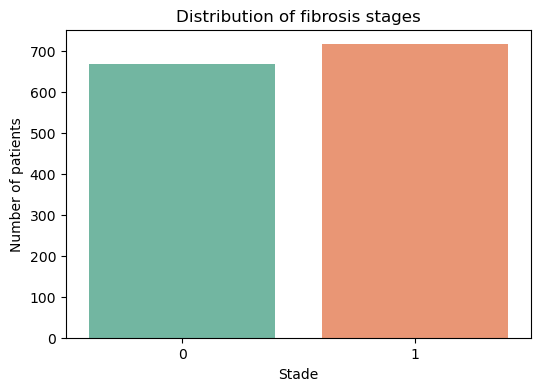

Raw distribution:
 baseline_histological_staging_binary
0    668
1    717
Name: count, dtype: int64

Proportions (%) :
 baseline_histological_staging_binary
0    48.23
1    51.77
Name: count, dtype: float64

Majority / minority ratio : 1.07


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot of the target variable
plt.figure(figsize=(6,4))
sns.countplot(x=y, palette="Set2")
plt.title("Distribution of fibrosis stages")
plt.xlabel("Stade")
plt.ylabel("Number of patients")
plt.show()

# Class counts
class_counts = y.value_counts().sort_index()
print("Raw distribution:\n", class_counts)

proportions = (class_counts / class_counts.sum() * 100).round(2)
print("\nProportions (%) :\n", proportions)

ratio = round(class_counts.max() / class_counts.min(), 2)
print("\nMajority / minority ratio :", ratio)


The target variable is almost balanced between the two classes. Early stages (0) represent about 48.23% of the patients, while advanced stages (1) represent about 51.77%. The majority/minority ratio is 1.07 which indicates a very slight imbalance. This means that class imbalance isn't an issue in this dataset, and we can apply models without using resampling techniques.

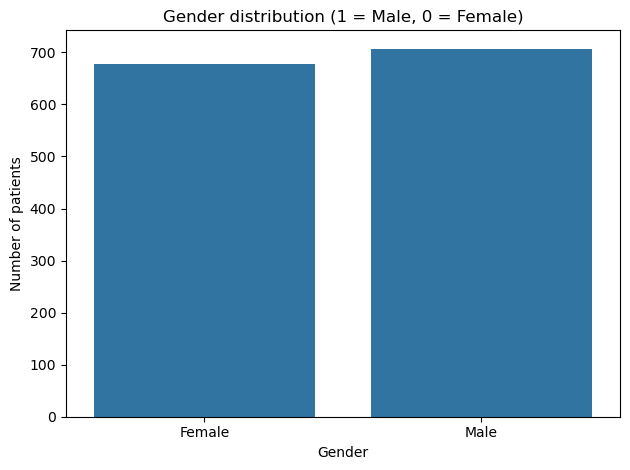

In [30]:
# Count plot of gender distribution
sns.countplot(x='gender_1', data=df_final_ordered)
plt.title("Gender distribution (1 = Male, 0 = Female)")
plt.xlabel("Gender")
plt.ylabel("Number of patients")
plt.xticks([0, 1], ['Female', 'Male'])
plt.tight_layout()
plt.show()

The gender distribution in the dataset is well balanced. The number of male and female patients is very similar, with a slight majority of male patients. This shows that the dataset provides a fair representation of both sexes for modeling.

C:\Users\estel\AppData\Local\Temp\ipykernel_24804\1282627883.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_distribution.index, y=age_distribution.values, palette="Blues_d")


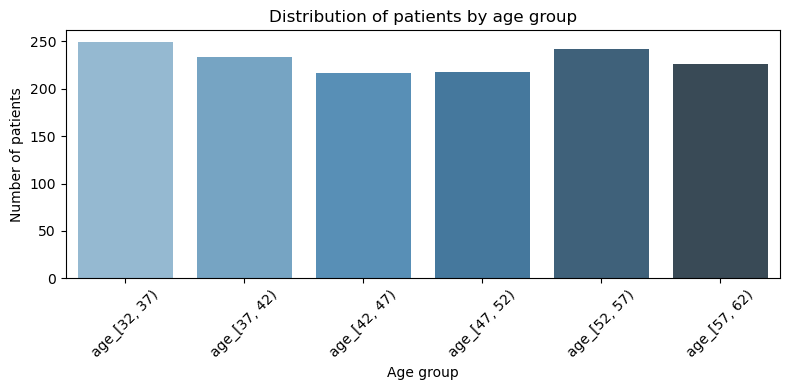

In [33]:
# Select age-related columns
age_cols = [col for col in df_final_ordered.columns if col.startswith("age_")]

# Compute the number of patients in each age group
age_distribution = df_final_ordered[age_cols].sum().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=age_distribution.index, y=age_distribution.values, palette="Blues_d")
plt.title("Distribution of patients by age group")
plt.xlabel("Age group")
plt.ylabel("Number of patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The age distribution shows that patients are fairly spread across all age groups. There is a slightly higher number of patients in the 32–37 and 52–57 age ranges, but there isn't an age group that dominates the dataset.This indicates that the model will be trained on a balanced representation of ages. It reduces the risk of age-related bias.

**STEP 3- Correlation analysis with the target**

C:\Users\estel\AppData\Local\Temp\ipykernel_24804\352893778.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pos.values, y=top_pos.index, palette="crest")


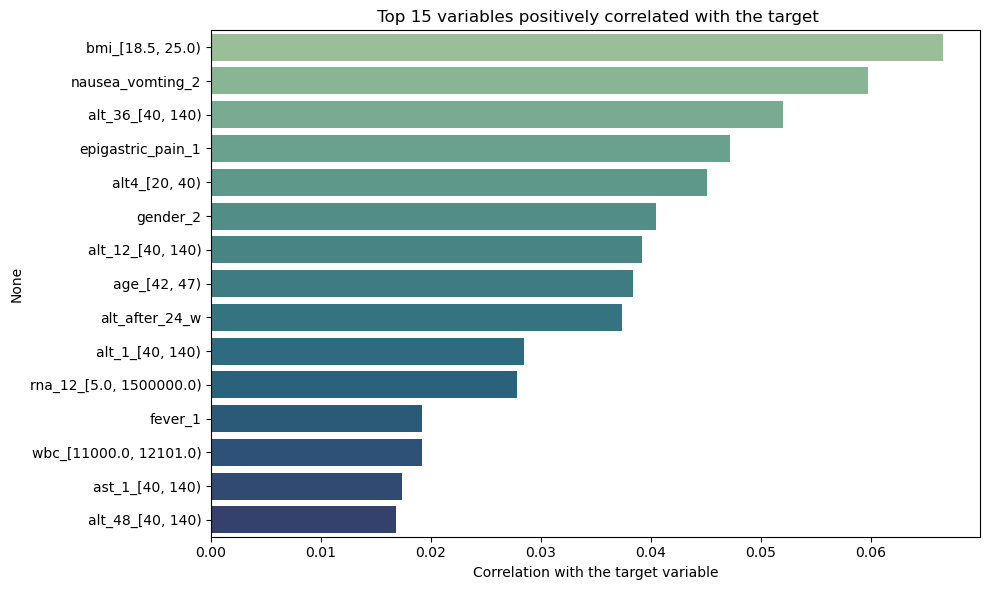

C:\Users\estel\AppData\Local\Temp\ipykernel_24804\352893778.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neg.values, y=top_neg.index, palette="rocket")


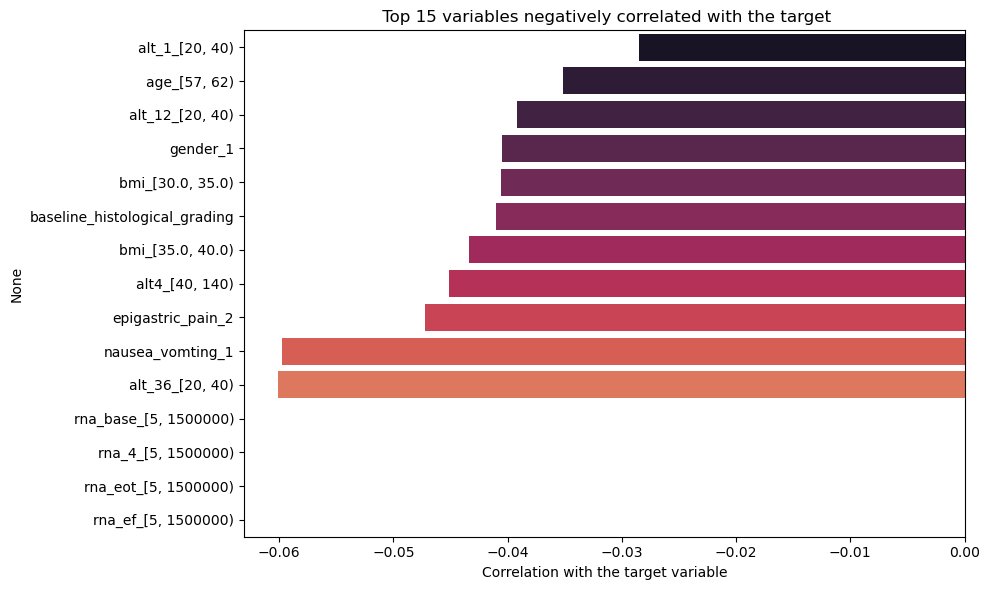

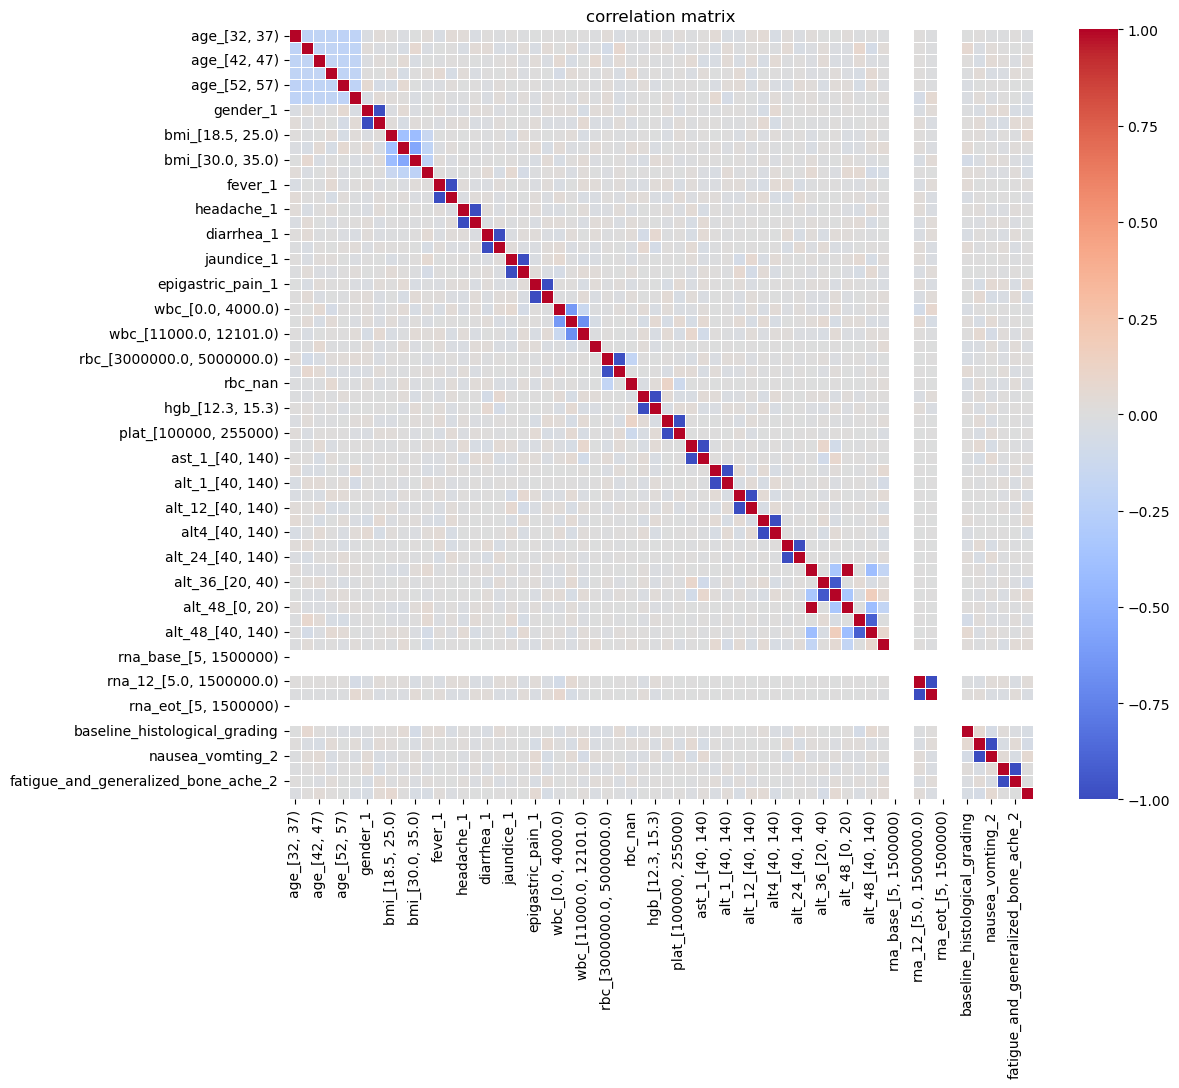

In [37]:
# Compute the correlation between each numerical variable and the target
correlations = df_final_ordered.corr(numeric_only=True)[target_col].drop(target_col)

# Sort correlations
top_corr = correlations.sort_values(ascending=False)

# Extract the 15 most and least correlated variables
top_pos = top_corr.head(15)
top_neg = top_corr.tail(15)

# Plot positive correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=top_pos.values, y=top_pos.index, palette="crest")
plt.title(" Top 15 variables positively correlated with the target")
plt.xlabel("Correlation with the target variable")
plt.tight_layout()
plt.show()

# Plot negative correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=top_neg.values, y=top_neg.index, palette="rocket")
plt.title(" Top 15 variables negatively correlated with the target")
plt.xlabel("Correlation with the target variable")
plt.tight_layout()
plt.show()

#Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df_final_ordered.corr(numeric_only=True), cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("correlation matrix")
plt.show()



The correlation analysis shows that several biological and clinical variables are associated with fibrosis stage. Some ALT levels, BMI ranges, RNA measurements, and symptoms are positively correlated with advanced stages,while other ranges are more common in early stages. We see that correlations are moderate, indicating that fibrosis stage depends on a combination of features and not only on a single variable.

**STEP 4: Visualization**

ALT4_[20,40) level by fibrosis stage

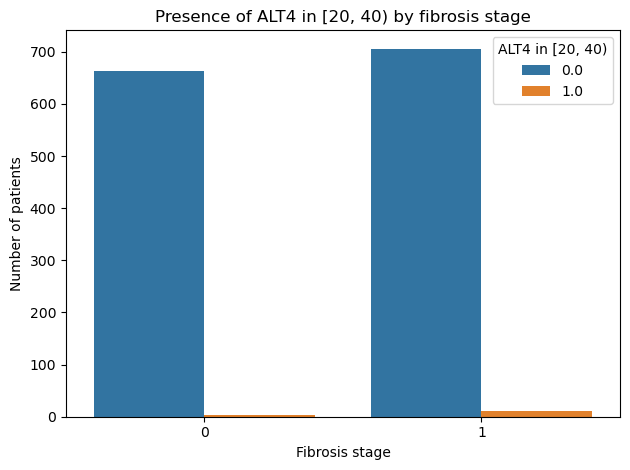

In [43]:
sns.countplot(x='baseline_histological_staging_binary', hue='alt4_[20, 40)', data=df_final_ordered)
plt.title("Presence of ALT4 in [20, 40) by fibrosis stage")
plt.xlabel("Fibrosis stage")
plt.ylabel("Number of patients")
plt.legend(title="ALT4 in [20, 40)")
plt.tight_layout()
plt.show()

This plot shows the presence of ALT4 values in the range [20,40) for early (0) and advanced (1) fibrosis stages. Patients in the early stage (0) are more likely to have ALT4 values in this interval compared to patients in the advanced stage (1). This suggests that ALT4 values in [20, 40) are more common in early fibrosis stages.

Gender distribution by fibrosis stage

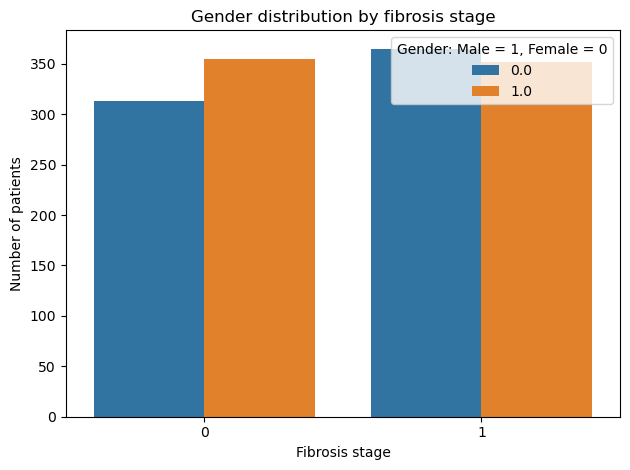

In [47]:
sns.countplot(x='baseline_histological_staging_binary', hue='gender_1', data=df_final_ordered)
plt.title("Gender distribution by fibrosis stage")
plt.xlabel("Fibrosis stage")
plt.ylabel("Number of patients")
plt.legend(title="Gender: Male = 1, Female = 0")
plt.tight_layout()
plt.show()


This plot shows the gender distribution across fibrosis stages.In the earlystage (0), male patients (1) are more numerous than female patients; In contrast, in the advanced stage (1), female patients (0) slightly dominate. This shows that gender distribution differs between fibrosis stages.

Distribution of age groups by fibrosis stage

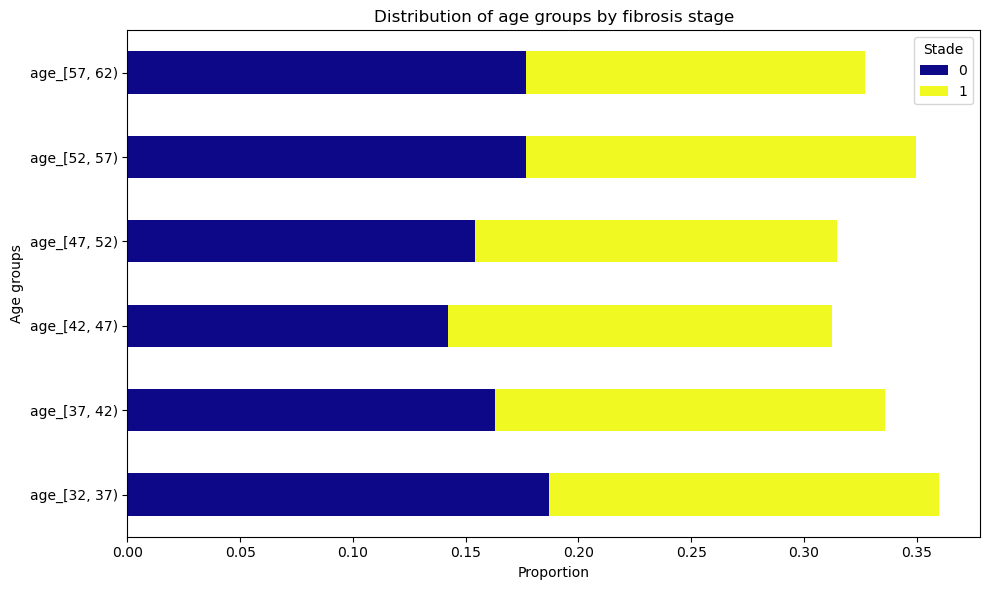

In [51]:
age_cols = [col for col in df_final_ordered.columns if col.startswith("age_")]
age_df = df_final_ordered[age_cols + ["baseline_histological_staging_binary"]]
age_dist = age_df.groupby("baseline_histological_staging_binary").mean().T

age_dist.plot(kind="barh", stacked=True, figsize=(10, 6), colormap="plasma")
plt.title("Distribution of age groups by fibrosis stage")
plt.xlabel("Proportion")
plt.ylabel("Age groups")
plt.legend(title="Stade")
plt.tight_layout()
plt.show()


This plot shows the distribution of age groups by fibrosis stage. For every age group, the advanced stage (1) represents a larger proportion than the early stage (0). The difference between the two stages is present across all age ranges meaning that the dataset contains more advanced cases in each age group. So, stage 1 is consistently more frequent.

Presence of nausea by fibrosis stage

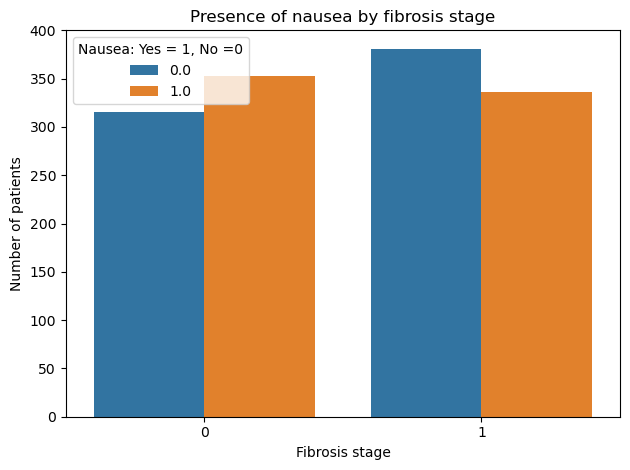

In [55]:
sns.countplot(x='baseline_histological_staging_binary', hue='nausea_vomting_1', data=df_final_ordered)
plt.title("Presence of nausea by fibrosis stage")
plt.xlabel("Fibrosis stage")
plt.ylabel("Number of patients")
plt.legend(title="Nausea: Yes = 1, No =0")
plt.tight_layout()
plt.show()


This plot shows the presence of nausea according to fibrosis stage. In the early stage (0), patients with nausea (1) are slightly more numerous than those without nausea. In contrast, in the advanced stage (1), patients without nausea (0) are more frequent than those reporting nausea.

This suggests that nausea is more commonly reported in early fibrosis stages and becomes less frequent as fibrosis progresses.

Epigastric pain by fibrosis stage

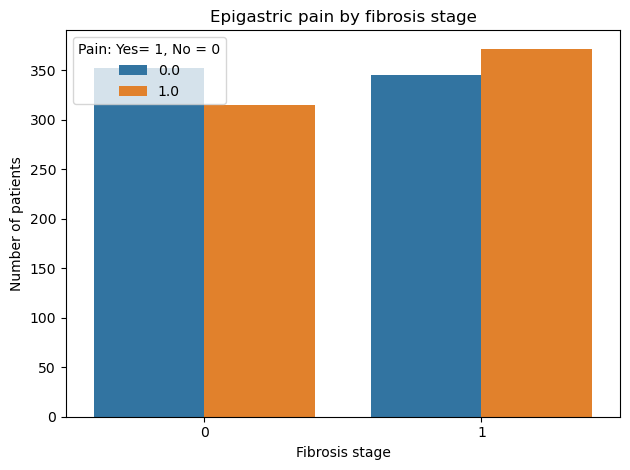

In [59]:
sns.countplot(x='baseline_histological_staging_binary', hue='epigastric_pain_1', data=df_final_ordered)
plt.title("Epigastric pain by fibrosis stage")
plt.xlabel("Fibrosis stage")
plt.ylabel("Number of patients")
plt.legend(title="Pain: Yes= 1, No = 0")
plt.tight_layout()
plt.show()


This plot shows the presence of epigastric pain by fibrosis stage. In the early stage (0), patients without epigastric pain (0) are more numerous than those with pain (1). In contrast, in the advanced stage (1), patients with epigastric pain (1) slightly dominate. So, epigastric pain tends to be more frequent in advanced fibrosis stages in this dataset.

Normal BMI by fibrosis stage

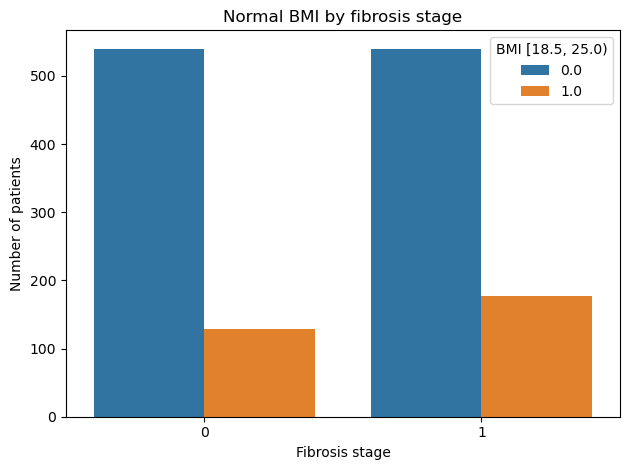

In [63]:
sns.countplot(x='baseline_histological_staging_binary', hue='bmi_[18.5, 25.0)', data=df_final_ordered)
plt.title("Normal BMI by fibrosis stage")
plt.xlabel("Fibrosis stage")
plt.ylabel("Number of patients")
plt.legend(title="BMI [18.5, 25.0)")
plt.tight_layout()
plt.show()


This plot shows the distribution of patients with a normal BMI (18.5–25.0) across fibrosis stages. In both early (0) and advanced (1) stages, most patients don't have a normal BMI. However, patients with a normal BMI are slightly more frequent in the advanced stage (1) than in the early stage (0).

**STEP 5: Preprocessing**